In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging
# Suppress INFO logs, show only WARNING and above
logging.getLogger().setLevel(logging.WARNING)


import numpy as np
import scanpy as sc
from repspat import compute_distances, spatial_silhouette_analysis, spatial_constrained_hac, plot_spatial_clusters, plot_cluster_feature_presence, pairwise_results_to_matrix, multiple_comparison, create_blocks


In [2]:
thresholds = {
    "betaCatenin": 0.253063192,
    "CD11b": 1.100536222,
    "CD11c": 0.213556566,
    "CD138": 1.038502303,
    "CD16": 0.304460727,
    "CD20": 0.296460556,
    "CD209": 0.406669859,
    "CD3": 0.250762424,
    "CD31": 1.006381212,
    "CD4": 0.223762,
    "CD45": 0.327450495,
    "CD45RO": 0.236334141,
    "CD56": 0.770183826,
    "CD63": 0.268126101,
    "CD68": 1.128510101,
    "CD8": 0.260237333,
    "dsDNA": 0.20301697,
    "EGFR": 1.069264889,
    "FoxP3": 0.34649899,
    "H3K27me3": 0.201893232,
    "H3K9ac": 0.406071229,
    "HLA_Class_1": 0.23773137,
    "HLADR": 0.4408116,
    "IDO": 0.312824202,
    "Keratin17": 0.291843697,
    "Keratin6": 0.282480556,
    "Ki67": 0.210413737,
    "Lag3": 1.239097091,
    "MPO": 0.324934545,
    "p53": 0.265704293,
    "panKeratin": 0.244129571,
    "PD1": 0.972859909,
    "PDL1": 1.352024101,
    "pS6": 0.282699091,
    "SMA": 0.250358024,
    "Vimentin": 0.28239596,
}

In [3]:
adata = sc.read_h5ad('../data/03_TNBC_2018_spe.h5ad')
missing = [marker for marker in adata.var_names if marker not in thresholds]
if missing:
    raise ValueError(f"Missing thresholds for: {missing}")
adata.layers["layer 1"] = adata.X.copy()
adata.X = None
X = adata.layers["layer 1"].toarray() if hasattr(adata.layers["layer 1"], "toarray") else adata.layers["layer 1"]
cutoffs = np.array([thresholds[marker] for marker in adata.var_names])
adata.layers["layer 2"] = (X >= cutoffs).astype(int)


In [4]:
adata = adata[adata.obs["sample_id"] == "Sample_04"].copy()


In [5]:
adata = compute_distances(
    adata,
    layer="layer 1",
    metric="euclidean",
)


In [6]:
{
    "feature_layer": adata.layers["layer 2"].shape,
    "coords_mat": adata.obsm["spatial"].shape,
    "dist_matrix": adata.obsp["repspat_distances"].shape,
    "adata": adata.shape,
}


{'feature_layer': (5381, 36),
 'coords_mat': (5381, 2),
 'dist_matrix': (5381, 5381),
 'adata': (5381, 36)}

In [7]:
adata.to_df(layer="layer 2")


,betaCatenin,CD11b,CD11c,CD138,CD16,CD20,CD209,CD3,CD31,CD4,...,Ki67,Lag3,MPO,p53,panKeratin,PD1,PDL1,pS6,SMA,Vimentin
Cell_1405,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
Cell_1406,0,0,1,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,1,0,1
Cell_1407,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
Cell_1408,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
Cell_1409,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cell_178418,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
Cell_178419,0,0,1,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,1
Cell_178420,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
Cell_178421,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,1


In [8]:
adata = spatial_silhouette_analysis(
    adata,
    n_neighbors_list=[6, 8],
    n_clusters_range=range(4, 9),
    linkage="ward",
)


INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  
Silhouette scores are stored in adata.uns["silhouette_scores"]


In [9]:
adata.uns["silhouette_scores"]


,n_neighbors,n_clusters,avg_silhouette
0,6,4,0.136721
1,6,5,0.086261
2,6,6,0.092815
3,6,7,0.113284
4,6,8,0.127881
5,8,4,0.161823
6,8,5,0.137023
7,8,6,0.148935
8,8,7,0.159307
9,8,8,0.122112


In [10]:
adata = spatial_constrained_hac(
    adata,
    n_clusters=7,
    n_neighs=8,
    linkage="ward",
)


INFO     Creating graph using `None` transform and `1` libraries.                                                  
HAC labels are stored in adata.obs["labels"]


(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'Spatial Plot of Cells with Cluster Colors'}, xlabel='X coordinate', ylabel='Y coordinate'>)

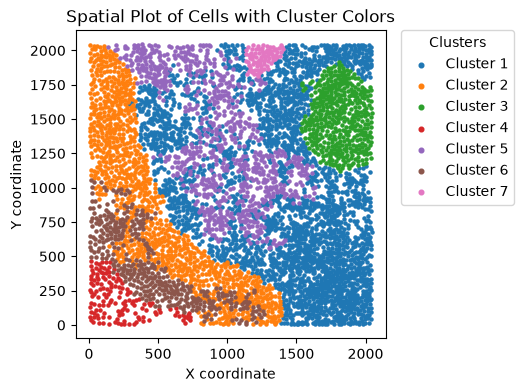

In [11]:
plot_spatial_clusters(adata,point_size=5)

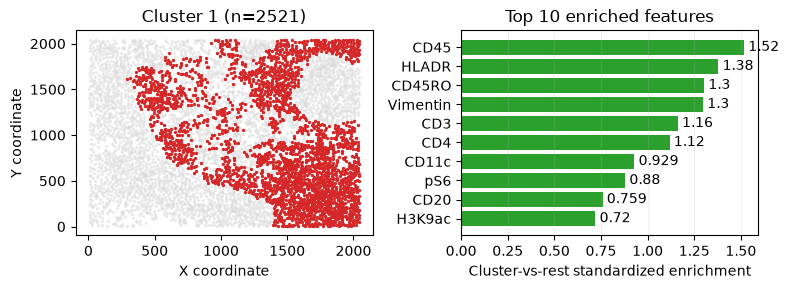

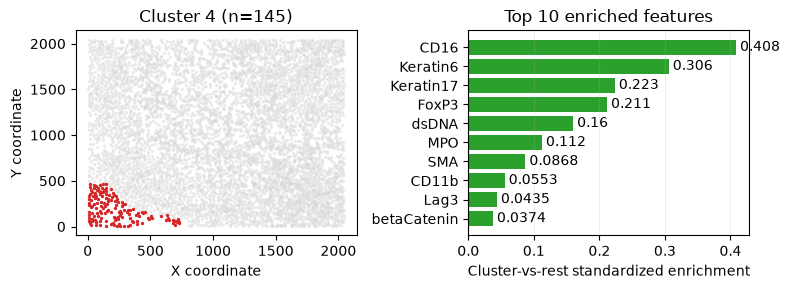

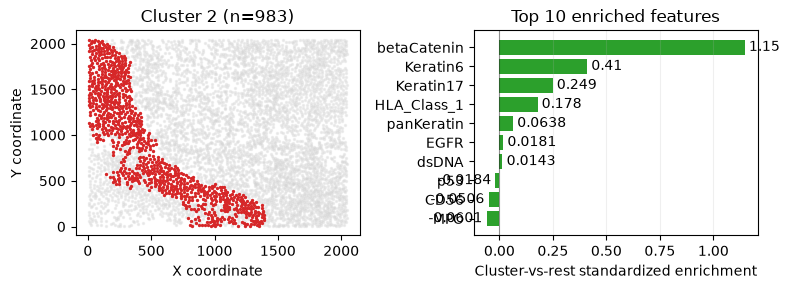

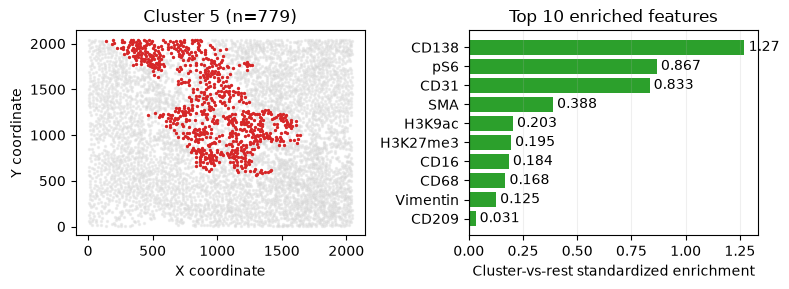

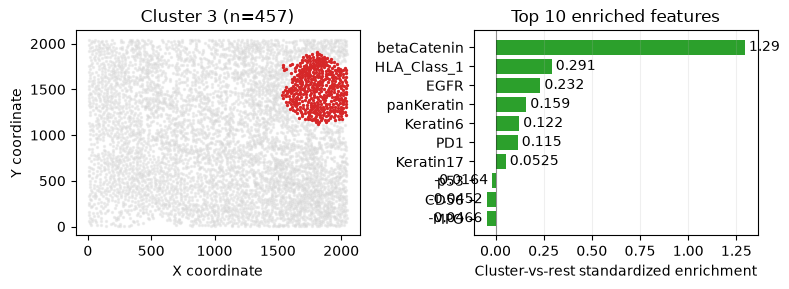

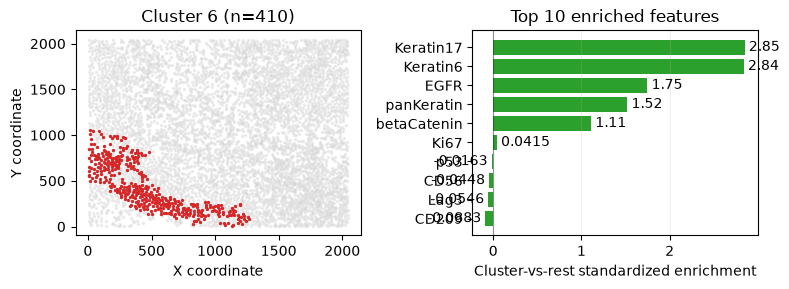

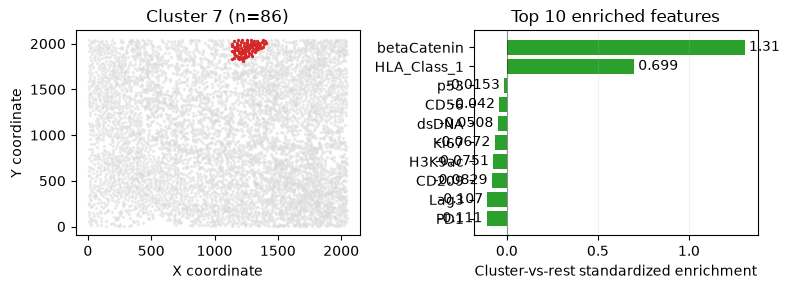

In [12]:
cluster_feature_plots = plot_cluster_feature_presence(adata, top_n=10, point_size=2)

In [13]:
adata = create_blocks(adata, knn=8)

In [14]:
adata = multiple_comparison(adata, kernel='IMQ')

MMD results are stored in adata.uns["repspat_mmd_results"]


In [15]:
adata.uns["repspat_mmd_results"][adata.uns["repspat_mmd_results"]["adj_p"] >= 0.05]

,region_1,region_2,obs_mmd_sq,p_value,null_dist,adj_p
12,2,3,0.007202,0.105,"[0.0013704637494211802, 0.003759780020267778, ...",0.110250
14,2,7,0.030408,0.080,"[0.04325263013102354, 0.008959840908200012, 0....",0.088421
19,3,7,0.014313,0.450,"[0.011521195760558323, 0.009123349937299463, 0...",0.450000


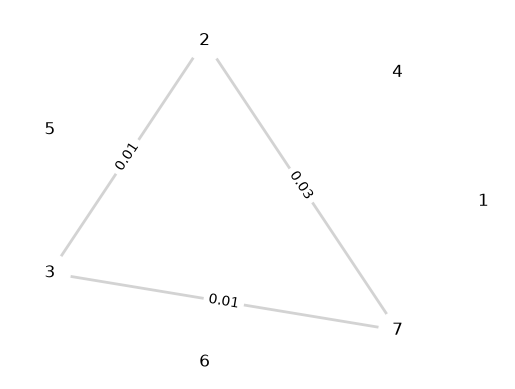

,1,4,2,5,3,6,7
1,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
4,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
2,0.0,0.0,0.000000,0.0,0.007202,0.0,0.030408
5,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
3,0.0,0.0,0.007202,0.0,0.000000,0.0,0.014313
6,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
7,0.0,0.0,0.030408,0.0,0.014313,0.0,0.000000


In [16]:
pairwise_results_to_matrix(adata)

In [17]:
adata.uns["repspat"]

{'layer': 'layer 1',
 'metric': 'euclidean',
 'distance_key': 'repspat_distances',
 'region_key': 'labels',
 'polygon_key': 'repspat_polygon_id'}